Natural disasters have a profound impact on human societies, economies, and environments. Understanding the patterns and consequences of these events can help in better preparedness and response strategies. In this notebook, we will explore a comprehensive dataset of global disasters to uncover insights and trends. If you find this analysis useful, please consider upvoting it.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load the dataset
file_path = '/kaggle/input/disaster-dataset/public_emdat_project.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,1999-9388-DJI,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,DJI,...,NaN,NaN,NaN,NaN,NaN,NaN,58.111474,"[{""adm1_code"":1093,""adm1_name"":""Ali Sabieh""},{...",2006-03-01,2023-09-25
1,1999-9388-SDN,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SDN,...,NaN,NaN,NaN,NaN,NaN,NaN,56.514291,"[{""adm1_code"":2757,""adm1_name"":""Northern Darfu...",2006-03-08,2023-09-25
2,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SOM,...,NaN,NaN,NaN,NaN,NaN,NaN,56.514291,"[{""adm1_code"":2691,""adm1_name"":""Bay""},{""adm1_c...",2006-03-08,2023-09-25
3,2000-0001-AGO,No,tec-tra-roa-roa,Technological,Transport,Road,Road,NaN,NaN,AGO,...,NaN,NaN,NaN,NaN,NaN,NaN,56.514291,NaN,2004-10-27,2023-09-25
4,2000-0002-AGO,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,AGO,...,NaN,NaN,NaN,NaN,10000.0,17695.0,56.514291,"[{""adm2_code"":4214,""adm2_name"":""Baia Farta""},{...",2005-02-03,2023-09-25


### Data Overview
Let's take a quick look at the structure of the dataset and understand the types of data we are dealing with.

In [4]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15784 entries, 0 to 15783
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     15784 non-null  object 
 1   Historic                                   15784 non-null  object 
 2   Classification Key                         15784 non-null  object 
 3   Disaster Group                             15784 non-null  object 
 4   Disaster Subgroup                          15784 non-null  object 
 5   Disaster Type                              15784 non-null  object 
 6   Disaster Subtype                           15784 non-null  object 
 7   External IDs                               2405 non-null   object 
 8   Event Name                                 4955 non-null   object 
 9   ISO                                        15784 non-null  object 
 10  Country               

### Data Cleaning
Before diving into the analysis, we need to clean the data. This includes handling missing values, converting date columns to appropriate formats, and ensuring numerical columns are correctly typed.

In [5]:
# Convert date columns to datetime format
df['Entry Date'] = pd.to_datetime(df['Entry Date'], errors='coerce')
df['Last Update'] = pd.to_datetime(df['Last Update'], errors='coerce')

In [6]:
# Handle missing values
df.fillna(0, inplace=True)

### Exploratory Data Analysis
Let's explore the data to uncover interesting patterns and insights.

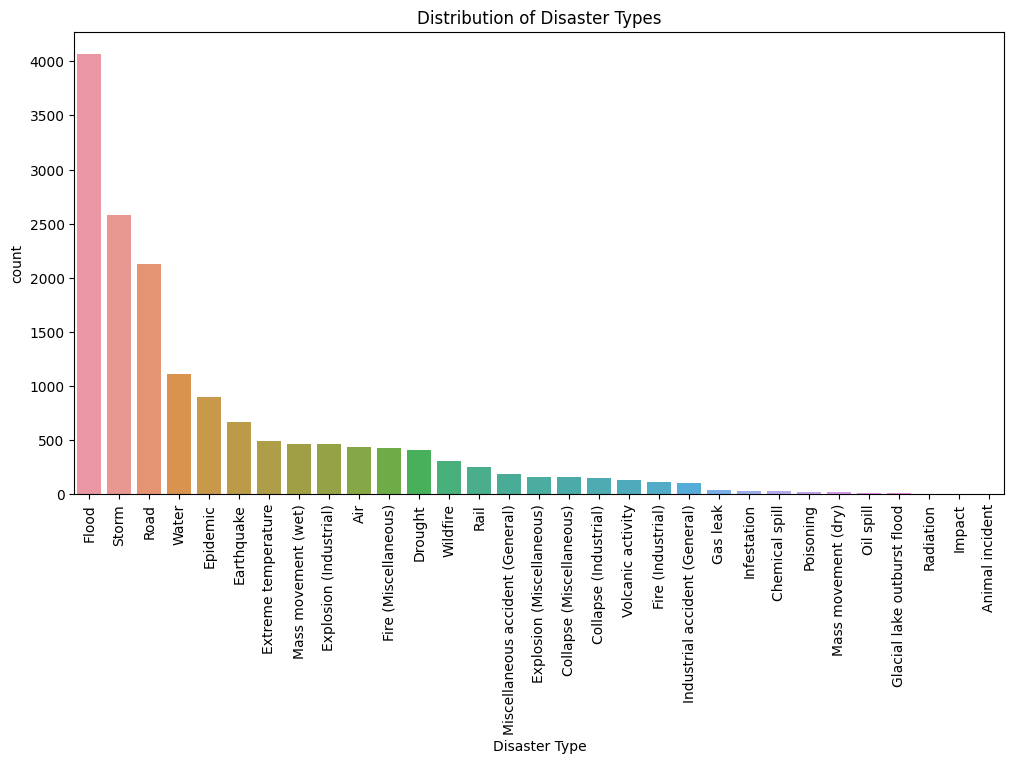

In [7]:
# Distribution of disaster types
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Disaster Type', order=df['Disaster Type'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Disaster Types')
plt.show()

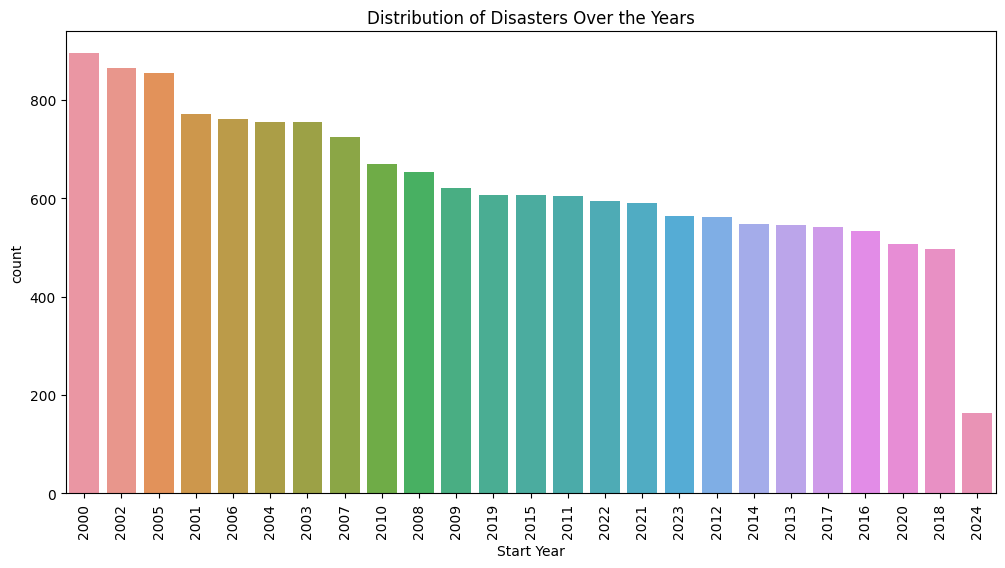

In [8]:
# Distribution of disasters over the years
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Start Year', order=df['Start Year'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Disasters Over the Years')
plt.show()

### Correlation Analysis
Let's examine the correlation between different numerical variables to understand their relationships.

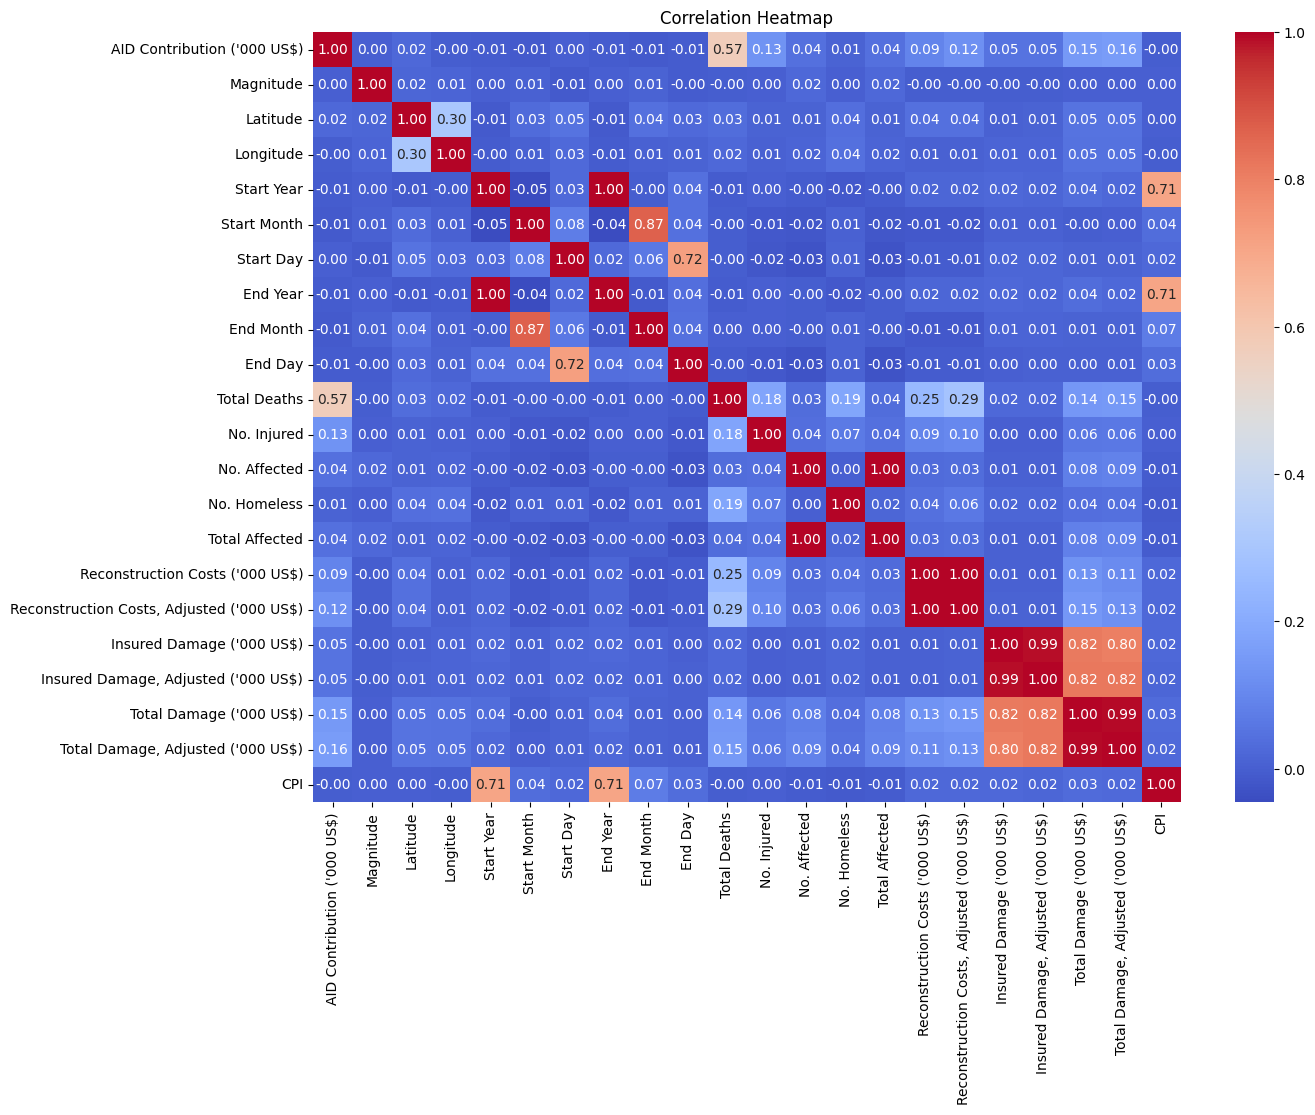

In [9]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Prediction Model
Based on the data, it might be useful to predict the type of disaster based on other features. Let's build a simple prediction model to do this.

In [10]:
# Prepare data for prediction
features = ['Start Year', 'End Year', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', 'Total Damage (\'000 US$)']
X = df[features]
y = df['Disaster Type']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

accuracy, conf_matrix, class_report

(0.4448902027027027,
 array([[ 14,   0,   0,   4,   1,   0,   1,   0,   6,   0,   5,   3,   6,
           8,   1,   0,   0,   2,   0,   0,   6,   2,   0,   0,   0,   6,
          41,   3,   0,  28,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   1,   0],
        [  0,   0,   0,   0,   0,   0,   1,   1,   0,   0,   0,   0,   0,
           1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
           0,   1,   0,   0,   3],
        [  2,   0,   0,   2,   1,   0,   0,   0,   3,   0,   1,   0,   4,
           1,   0,   0,   0,   2,   0,   0,   0,   1,   0,   0,   0,   1,
          15,   1,   0,  11,   0],
        [  2,   0,   0,   0,   0,   0,   2,   0,   4,   1,   1,   1,   4,
           1,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   3,
          20,   0,   0,   2,   0],
        [  1,   0,   0,   0,   0,  50,   0,   1,   0,   0,   5, 

### Future Analysis
There are numerous directions for future analysis. For instance, we could explore the impact of specific disaster types on different regions, or analyze the effectiveness of aid contributions. What do you think would be useful to investigate further?

If you found this notebook useful, please consider upvoting it.

## Credits
This notebook was created with the help of [Devra AI data science assistant](https://devra.ai/ref/kaggle)